<a href="https://colab.research.google.com/github/Shahul187/aml-alert-triage/blob/main/notebooks/06_visualisations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base = '/content/drive/MyDrive/aml-project/'
alerts = pd.read_csv(base + 'scored_alerts.csv')
pk     = pd.read_csv(base + 'precision_at_k.csv')
rules_cov = pd.read_csv(base + 'rule_performance.csv', index_col=0)
model_cov = pd.read_csv(base + 'model_pattern_coverage.csv', index_col=0)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.facecolor': 'white',
})

print(f"alerts {alerts.shape} | pk {pk.shape} | model_cov {model_cov.shape}")
print(alerts.columns.tolist())

Mounted at /content/drive
alerts (56544, 9) | pk (5, 6) | model_cov (17, 3)
['Date', 'Amount', 'is_cash', 'is_crossborder', 'Is_laundering', 'Laundering_type', 'model_score', 'in_top_5pct', 'hybrid_flag']


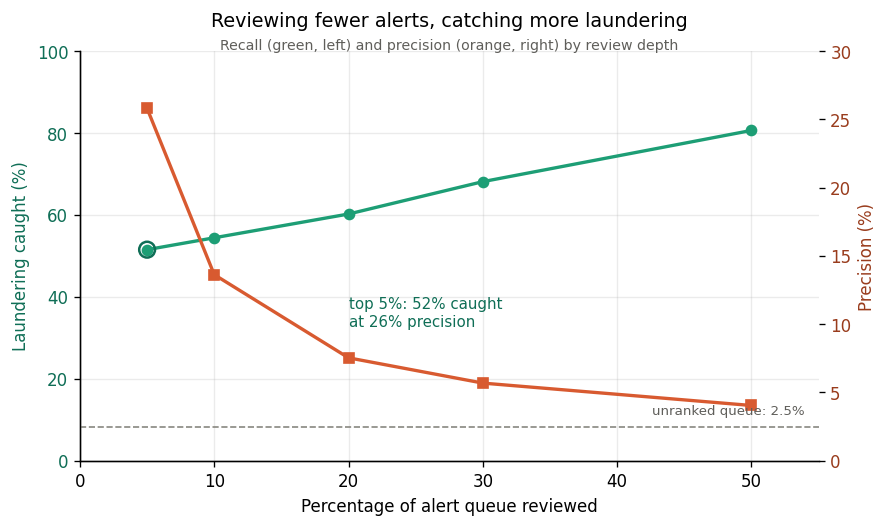

In [11]:
fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
ax1.plot(k_pct, recall, marker='o', color='#1d9e75', lw=2)
ax1.set_xlabel('Percentage of alert queue reviewed')
ax1.set_ylabel('Laundering caught (%)', color='#0f6e56')
ax1.set_ylim(0, 100); ax1.set_xlim(0, 55)
ax1.tick_params(axis='y', labelcolor='#0f6e56')

ax2 = ax1.twinx()
ax2.plot(k_pct, precision, marker='s', color='#d85a30', lw=2)
ax2.set_ylabel('Precision (%)', color='#993c1d')
ax2.set_ylim(0, 30); ax2.grid(False)
ax2.tick_params(axis='y', labelcolor='#993c1d')
ax2.axhline(2.5, ls='--', color='#888780', lw=1)
ax2.text(54, 3.4, 'unranked queue: 2.5%', fontsize=8, color='#5f5e5a', ha='right')

ax1.scatter([5], [recall[0]], s=90, facecolor='none',
            edgecolor='#0f6e56', lw=1.5, zorder=5)
ax1.text(20, 40, 'top 5%: 52% caught\nat 26% precision',
         fontsize=9, color='#0f6e56', va='top')

ax1.text(0.5, 1.06, 'Reviewing fewer alerts, catching more laundering',
         transform=ax1.transAxes, ha='center', fontsize=11.5)
ax1.text(0.5, 1.005, 'Recall (green, left) and precision (orange, right) by review depth',
         transform=ax1.transAxes, ha='center', fontsize=8.5, color='#5f5e5a')
fig.tight_layout()
fig.savefig(base + 'chart_precision_at_k.png', bbox_inches='tight')
plt.show()

In [3]:
print(pk.to_string(index=False))

review_top_%  alerts_reviewed  caught  precision_%  recall_%  workload_saved_%
          5%             2827     729        25.79      51.5                95
         10%             5654     770        13.62      54.4                90
         20%            11308     852         7.53      60.2                80
         30%            16963     964         5.68      68.1                70
         50%            28272    1141         4.04      80.6                50


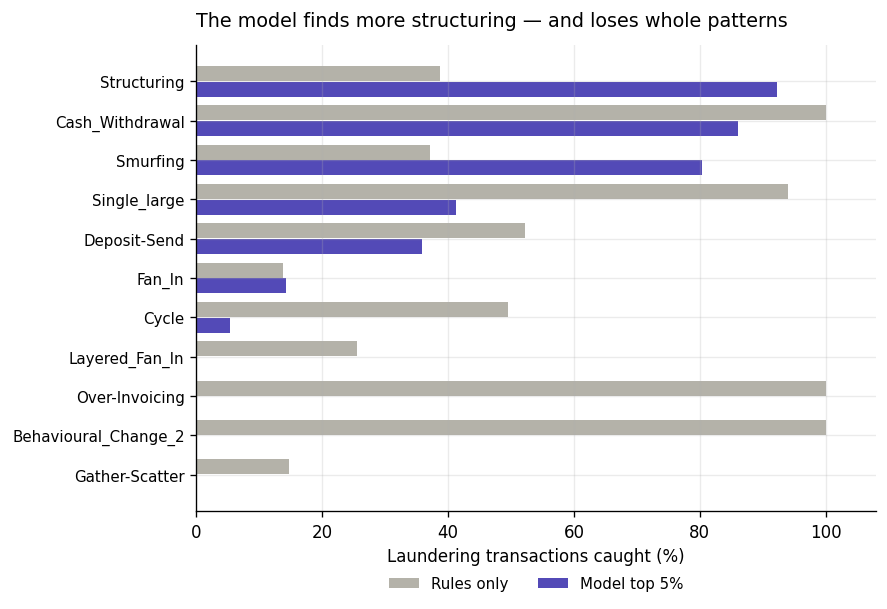

In [9]:
comp2 = comp.sort_values('model', ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 5.2))
y = np.arange(len(comp2))
ax.barh(y-0.2, comp2['rules'], height=0.38, color='#b4b2a9', label='Rules only')
ax.barh(y+0.2, comp2['model'], height=0.38, color='#534ab7', label='Model top 5%')
ax.set_yticks(y); ax.set_yticklabels(comp2.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Laundering transactions caught (%)')
ax.set_xlim(0, 108)
ax.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.11),
          ncol=2, frameon=False)
ax.text(0, 1.04, 'The model finds more structuring — and loses whole patterns',
        transform=ax.transAxes, fontsize=11.5)
fig.tight_layout()
fig.savefig(base + 'chart_coverage_comparison.png', bbox_inches='tight')
plt.show()

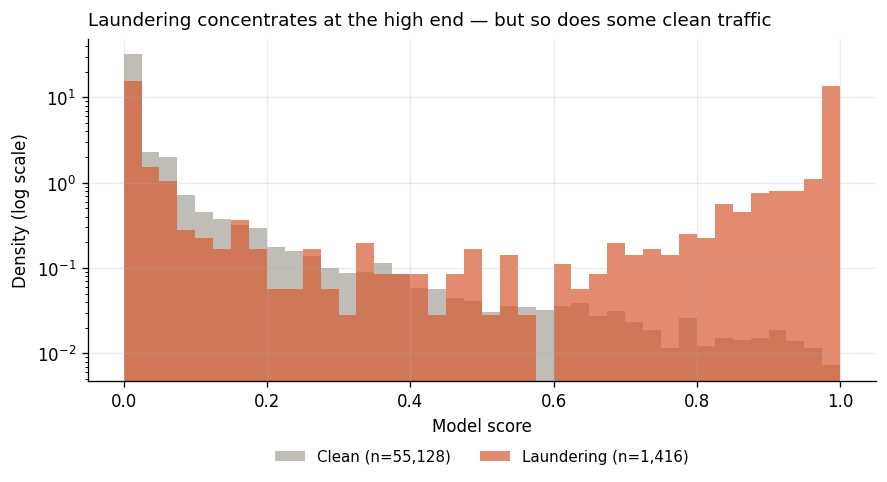

In [13]:
clean = alerts.loc[alerts['Is_laundering']==0, 'model_score']
crime = alerts.loc[alerts['Is_laundering']==1, 'model_score']

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bins = np.linspace(0, 1, 41)
ax.hist(clean, bins=bins, color='#b4b2a9', alpha=0.85, label=f'Clean (n={len(clean):,})', density=True)
ax.hist(crime, bins=bins, color='#d85a30', alpha=0.7, label=f'Laundering (n={len(crime):,})', density=True)
ax.set_yscale('log')
ax.set_xlabel('Model score')
ax.set_ylabel('Density (log scale)')
ax.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.16),
          ncol=2, frameon=False)
ax.text(0, 1.04, 'Laundering concentrates at the high end — but so does some clean traffic',
        transform=ax.transAxes, fontsize=11)
fig.tight_layout()
fig.savefig(base + 'chart_score_distribution.png', bbox_inches='tight')
plt.show()

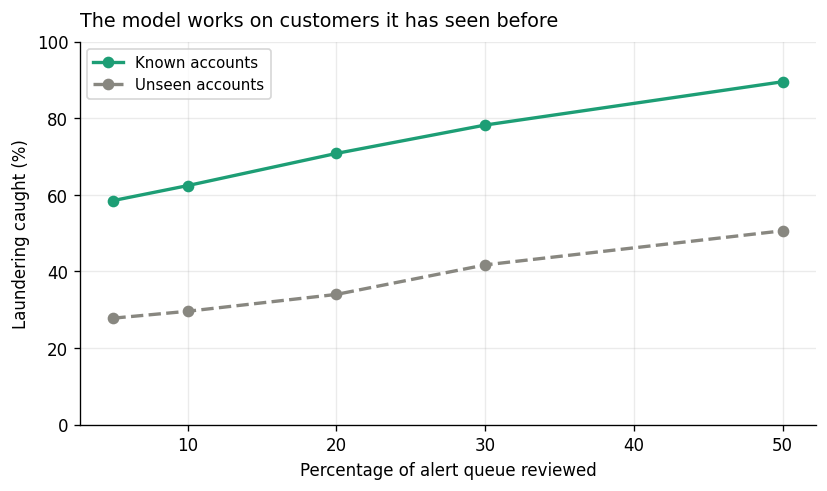

In [14]:
seg = pd.DataFrame({
    'Known accounts': [58.5, 62.4, 70.8, 78.2, 89.5],
    'Unseen accounts': [27.8, 29.6, 34.0, 41.7, 50.6]}, index=k_pct)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(seg.index, seg['Known accounts'], marker='o', color='#1d9e75', lw=2, label='Known accounts')
ax.plot(seg.index, seg['Unseen accounts'], marker='o', color='#888780', lw=2, ls='--', label='Unseen accounts')
ax.set_xlabel('Percentage of alert queue reviewed')
ax.set_ylabel('Laundering caught (%)')
ax.set_ylim(0, 100); ax.legend(fontsize=9)
ax.text(0, 1.04, 'The model works on customers it has seen before',
        transform=ax.transAxes, fontsize=11.5)
fig.tight_layout()
fig.savefig(base + 'chart_segment_comparison.png', bbox_inches='tight')
plt.show()